In [14]:
pip install pandas numpy matplotlib openpyxl scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



================ DANH SÁCH SINH VIÊN GIỎI ================

             MSSV      Tên Sinh Viên   GPA
14  K225480106009    Trần Thị Thu Hà  3.48
15  K225480106013     Lường Văn Hạnh  3.34
20  K225480106019  Nguyễn Trung Hiếu  3.29
46  K225480106053     Hoàng Kim Ngọc  3.37
56  K225480106058  Nguyễn Tiến Thắng  3.25

================ DANH SÁCH SINH VIÊN KHÁ ================

             MSSV           Tên Sinh Viên   GPA
5   K225480106100            Lý Văn Cường  2.99
7   K225480106007        Nguyễn Thế Dương  2.65
8   K225480106093        Nguyễn Đức Dương  3.18
9   K225480106003           Đặng Đình Đạt  2.82
17  K225480106015     Nguyễn Thị Thu Hiền  3.18
18  K225480106016      Hứa Thị Thanh Hiền  3.14
21  K225480106020        Nguyễn Mạnh Hiếu  2.75
23  K225480106025           Lương Văn Học  2.91
25  K225480106026      Nguyễn Thị Kim Huệ  2.97
26  K225480106027     Hầu Thị Thanh Huyền  2.97
28  K225480106099           Đậu Văn Khánh  3.18
29  K225480106030        Nguyễn Như Khiêm  3.

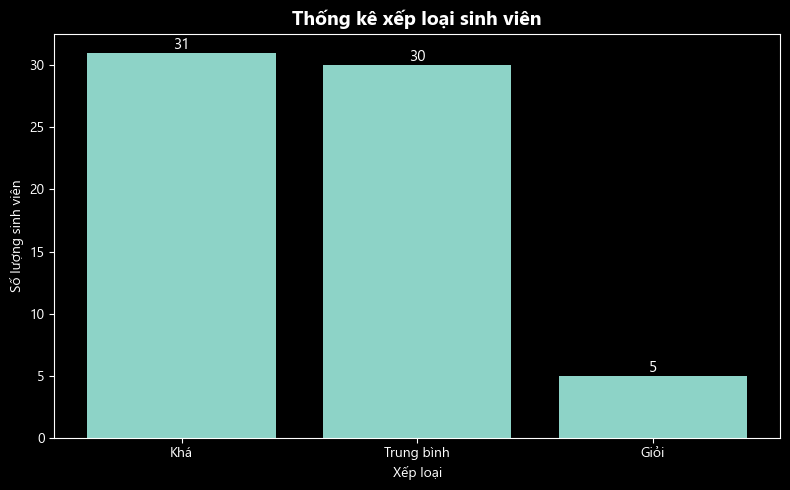

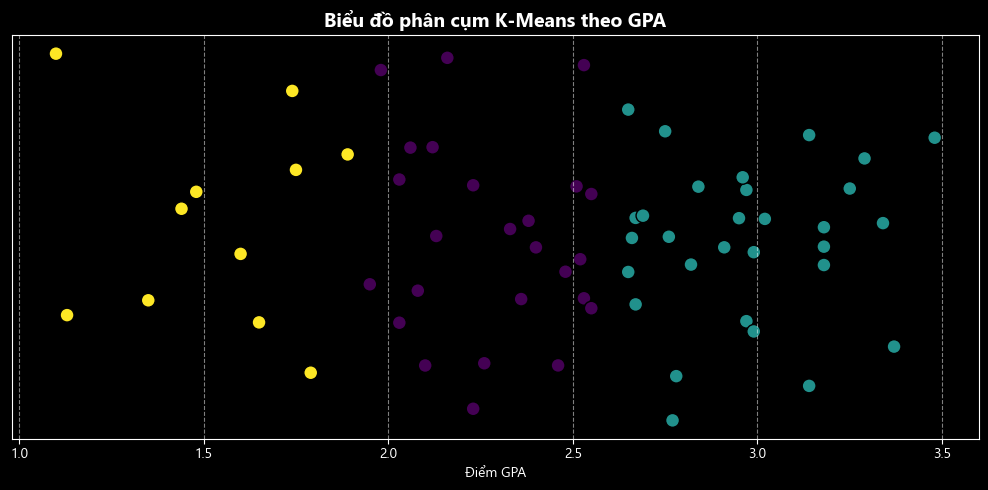

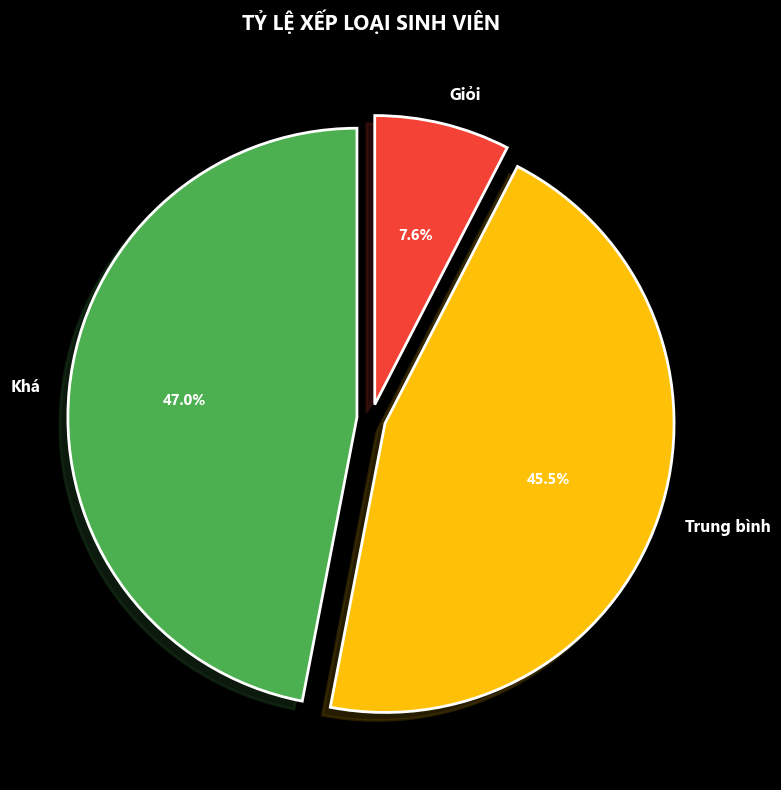


ĐÃ XUẤT FILE EXCEL THÀNH CÔNG
Tên file: KetQua_XepLoai_GPA.xlsx
Đã lưu biểu đồ: bieu_do_xep_loai.png


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl

from openpyxl.styles import (
    Font,
    PatternFill,
    Alignment,
    Border,
    Side
)

# =========================================================
# 1. ĐỌC FILE EXCEL
# =========================================================

try:
    df = pd.read_excel(
        "BangDiemK58KTP.xlsx",
        header=None
    )

except FileNotFoundError:

    print("Không tìm thấy file Excel!")
    exit()

# =========================================================
# 2. LẤY THÔNG TIN SINH VIÊN
# =========================================================

# MSSV
mssv = df.iloc[1, 3:].values

# Tên sinh viên
ten_sv = df.iloc[2, 3:].values

# Bảng điểm
scores_df = df.iloc[4:56, 3:].copy()

# Chuyển về số
scores_df = scores_df.apply(
    pd.to_numeric,
    errors='coerce'
)

# =========================================================
# 3. XỬ LÝ DỮ LIỆU
# =========================================================

# Xóa cột toàn NaN
empty_cols = scores_df.columns[
    scores_df.isna().all(axis=0)
]

scores_df = scores_df.drop(
    columns=empty_cols
)

# Đồng bộ MSSV và tên
mssv = np.delete(
    mssv,
    [c - 3 for c in empty_cols]
)

ten_sv = np.delete(
    ten_sv,
    [c - 3 for c in empty_cols]
)

# Các ô trống còn lại = 0
scores_df = scores_df.fillna(0)

# =========================================================
# 4. TÍNH GPA
# =========================================================

gpa = scores_df.mean(axis=0)

# Tạo DataFrame kết quả
result_df = pd.DataFrame({

    "MSSV": mssv,
    "Tên Sinh Viên": ten_sv,
    "GPA": gpa.values

})

# Làm tròn GPA
result_df["GPA"] = result_df["GPA"].round(2)

# =========================================================
# 5. XẾP LOẠI HỌC LỰC
# =========================================================

def classify(gpa):

    # Giỏi
    if 3.2 <= gpa <= 3.59:
        return "Giỏi"

    # Khá
    elif 2.5 <= gpa <= 3.19:
        return "Khá"

    # Trung bình
    else:
        return "Trung bình"

# Áp dụng phân loại
result_df["Xếp loại"] = result_df["GPA"].apply(classify)

# =========================================================
# 6. HIỂN THỊ DANH SÁCH THEO XẾP LOẠI
# =========================================================

# ---------------- GIỎI ----------------

gioi_df = result_df[
    result_df["Xếp loại"] == "Giỏi"
]

print("\n================ DANH SÁCH SINH VIÊN GIỎI ================\n")

print(
    gioi_df[
        ["MSSV", "Tên Sinh Viên", "GPA"]
    ]
)

# ---------------- KHÁ ----------------

kha_df = result_df[
    result_df["Xếp loại"] == "Khá"
]

print("\n================ DANH SÁCH SINH VIÊN KHÁ ================\n")

print(
    kha_df[
        ["MSSV", "Tên Sinh Viên", "GPA"]
    ]
)

# ---------------- TRUNG BÌNH ----------------

tb_df = result_df[
    result_df["Xếp loại"] == "Trung bình"
]

print("\n================ DANH SÁCH SINH VIÊN TRUNG BÌNH ================\n")

print(
    tb_df[
        ["MSSV", "Tên Sinh Viên", "GPA"]
    ]
)

# =========================================================
# 7. THỐNG KÊ
# =========================================================

print("\n================ THỐNG KÊ ================\n")

print(
    result_df["Xếp loại"].value_counts()
)

# =========================================================
# 8. BIỂU ĐỒ THỐNG KÊ
# =========================================================

from sklearn.cluster import KMeans

# ---------------------------------------------------------
# BIỂU ĐỒ CỘT
# ---------------------------------------------------------

counts = result_df["Xếp loại"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    counts.index,
    counts.values
)

plt.title(
    "Thống kê xếp loại sinh viên",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Xếp loại")
plt.ylabel("Số lượng sinh viên")

# Hiển thị số trên cột
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()

# Lưu ảnh
plt.savefig(
    "bieu_do_cot.png",
    dpi=300
)

# Hiển thị
plt.show()

# ---------------------------------------------------------
# BIỂU ĐỒ PHÂN CỤM K-MEANS
# ---------------------------------------------------------

# Dữ liệu GPA
X = result_df[["GPA"]]

# KMeans 3 cụm
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Dự đoán cụm
result_df["Cluster"] = kmeans.fit_predict(X)

# Tạo jitter để nhìn rõ điểm
y_jitter = np.random.normal(
    0,
    0.03,
    size=len(result_df)
)

plt.figure(figsize=(10, 5))

scatter = plt.scatter(
    result_df["GPA"],
    y_jitter,
    c=result_df["Cluster"],
    s=100,
    edgecolors='black'
)

plt.title(
    "Biểu đồ phân cụm K-Means theo GPA",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Điểm GPA")
plt.yticks([])

plt.grid(
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

# Lưu ảnh
plt.savefig(
    "bieu_do_kmeans.png",
    dpi=300
)

# Hiển thị
plt.show()

# ---------------------------------------------------------
# BIỂU ĐỒ TRÒN
# ---------------------------------------------------------

labels = counts.index
sizes = counts.values

# Màu sắc
colors = [
    "#4CAF50",   # Xanh lá - Giỏi
    "#FFC107",   # Vàng - Khá
    "#F44336"    # Đỏ - Trung bình
]

# Tách nhẹ các phần
explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(

    sizes,

    labels=labels,

    colors=colors,

    explode=explode,

    autopct='%1.1f%%',

    startangle=90,

    shadow=True,

    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2
    },

    textprops={
        'fontsize': 12,
        'fontweight': 'bold'
    }
)

# Chỉnh chữ phần trăm
for autotext in autotexts:

    autotext.set_color('white')
    autotext.set_fontsize(11)

plt.title(
    "TỶ LỆ XẾP LOẠI SINH VIÊN",
    fontsize=15,
    fontweight='bold',
    pad=20
)

plt.tight_layout()

# Lưu ảnh
plt.savefig(
    "bieu_do_tron.png",
    dpi=300
)

# Hiển thị
plt.show()

# Hiển thị
plt.show()

# HIỂN THỊ BIỂU ĐỒ
plt.show()

# =========================================================
# 9. XUẤT FILE EXCEL
# =========================================================

wb = openpyxl.Workbook()

ws = wb.active

ws.title = "Kết quả GPA"

# =========================================================
# STYLE
# =========================================================

header_fill = PatternFill(
    start_color="1F4E78",
    end_color="1F4E78",
    fill_type="solid"
)

header_font = Font(
    bold=True,
    color="FFFFFF"
)

center = Alignment(
    horizontal="center",
    vertical="center"
)

thin = Side(
    border_style="thin",
    color="000000"
)

border = Border(
    left=thin,
    right=thin,
    top=thin,
    bottom=thin
)

# =========================================================
# TIÊU ĐỀ
# =========================================================

ws.merge_cells("A1:D1")

ws["A1"] = "DANH SÁCH XẾP LOẠI SINH VIÊN"

ws["A1"].font = Font(
    size=15,
    bold=True
)

ws["A1"].alignment = center

# =========================================================
# HEADER
# =========================================================

headers = [
    "MSSV",
    "Tên Sinh Viên",
    "GPA",
    "Xếp loại"
]

for col, header in enumerate(headers, start=1):

    cell = ws.cell(
        row=3,
        column=col,
        value=header
    )

    cell.fill = header_fill
    cell.font = header_font
    cell.alignment = center
    cell.border = border

# =========================================================
# GHI DỮ LIỆU
# =========================================================

for idx, row in result_df.iterrows():

    ws.cell(idx + 4, 1, row["MSSV"])
    ws.cell(idx + 4, 2, row["Tên Sinh Viên"])
    ws.cell(idx + 4, 3, row["GPA"])
    ws.cell(idx + 4, 4, row["Xếp loại"])

    for col in range(1, 5):

        cell = ws.cell(idx + 4, col)

        cell.border = border

        if col != 2:
            cell.alignment = center

# =========================================================
# CHỈNH ĐỘ RỘNG CỘT
# =========================================================

ws.column_dimensions['A'].width = 18
ws.column_dimensions['B'].width = 30
ws.column_dimensions['C'].width = 12
ws.column_dimensions['D'].width = 15

# =========================================================
# LƯU FILE
# =========================================================

output_file = "KetQua_XepLoai_GPA.xlsx"

wb.save(output_file)

print("\n===================================")
print("ĐÃ XUẤT FILE EXCEL THÀNH CÔNG")
print("Tên file:", output_file)
print("Đã lưu biểu đồ: bieu_do_xep_loai.png")
print("===================================")